# Bi-Rotor Control System Simulation (PID Controller)

## Overview
This notebook implements a **bi-rotor (dual-rotor) aerial vehicle control system** with dynamic modeling and cascaded PID control. The system includes:
- **Quadcopter dynamics** with full 6-DOF rigid body motion
- **Cascaded PID controller** for position and attitude tracking
- **Variable thrust vectoring** on two rotors with tilt angles (pitch and roll)
- **Simulation and trajectory tracking** with visualization

## System Architecture
The implementation consists of three main components:
1. **Helper Functions**: Kinematic transformations and angle management
2. **Quadcopter Dynamics**: Rigid body equations of motion
3. **Cascaded PID Controller**: Four nested control loops for position and attitude
4. **Main Simulation**: Time-step integration and trajectory tracking

## Key Parameters
- **Mass**: 1.5 kg
- **Inertia Matrix**: Diagonal with Ixx=Iyy=0.015 kg·m², Izz=0.03 kg·m²
- **Max Tilt Angle**: 40°
- **Arm Length (l)**: 0.3 m
- **Rotor Geometry**: b1=0.03 m, b2=0.05 m, c1=0.03 m

## Import Libraries
All necessary scientific and visualization libraries are imported below.

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

## Helper Functions

### Description
These utility functions handle kinematic transformations and angle management for the control system.

### Functions Included
- **eulerKinematicMatrix()**: Converts angular velocities (p, q, r) to Euler angle rates (φ̇, θ̇, ψ̇)
- **clampAngles()**: Enforces tilt angle limits (±30° default) for rotor servos
- **wrapToPi()**: Wraps angles to [-π, π] range to handle angle discontinuities

In [ ]:
#Rotation Transformation Matrix
def eulerKinematicMatrix(phi, theta):
    T = np.array([
        [1, np.sin(phi)*np.tan(theta), np.cos(phi)*np.tan(theta)],
        [0, np.cos(phi), -np.sin(phi)],
        [0, np.sin(phi)/np.cos(theta), np.cos(phi)/np.cos(theta)]
    ])
    return T

#Clamps angles alpha and beta within its limits (+30,-30)
def clampAngles(alpha1, alpha2, beta1, beta2, max_limit):
    # Clamp each angle between -max_limit and +max_limit
    alpha1_clamped = max(min(alpha1, max_limit), -max_limit)
    alpha2_clamped = max(min(alpha2, max_limit), -max_limit)
    beta1_clamped = max(min(beta1, max_limit), -max_limit)
    beta2_clamped = max(min(beta2, max_limit), -max_limit)
    return alpha1_clamped, alpha2_clamped, beta1_clamped, beta2_clamped

#Wraps angle within -pi,pi. If angle gets above 360 degree it means there is one complete rotation and second rotation again starts with pi
def wrapToPi(angle):
    # Wrap angle to [-π, π]
    return (angle + np.pi) % (2 * np.pi) - np.pi

## Quadcopter Dynamics Model

### Overview
The `Quadcopter` class implements the **rigid body dynamics** of the aerial vehicle using Newton-Euler equations.

### State Vector (12-D)
```
x = [x, y, z, vx, vy, vz, p, q, r, φ, θ, ψ]
```
- **Position (0-2)**: x, y, z coordinates in inertial frame
- **Velocity (3-5)**: vx, vy, vz in inertial frame
- **Angular Velocity (6-8)**: p, q, r (body rates in body frame)
- **Attitude (9-11)**: φ (roll), θ (pitch), ψ (yaw) - ZYX Euler angles

### Key Equations
- **Translational Dynamics**: $\ddot{x} = R F_b / m - g \hat{z}$
- **Rotational Dynamics**: $\varphi = J^{-1}(M_b - \omega \times J\omega)$
- **Attitude Kinematics**: $\dot{\Theta} = T(\Theta) \omega$ where $T$ is the Euler kinematic matrix

### Inputs
- **F_b**: Total force in body frame (from rotor thrusts)
- **M_b**: Total moment/torque in body frame

In [ ]:
#Quad model and its dynamic model.
class Quadcopter:
    def __init__(self, mass, J, gravity):
        self.mass = mass
        self.J = J
        self.gravity = gravity

    def dynamics(self, x, t, F_b, M_b):
        pos = x[0:3]
        vel = x[3:6]
        omega = x[6:9]
        angles = x[9:12]
        phi, theta, psi = angles

        # Ensure angles are within [-π, π]
        phi = wrapToPi(phi)
        theta = wrapToPi(theta)
        psi = wrapToPi(psi)

        # Rotation matrix from body to inertial frame (ZYX convention)
        R = np.array([
            [np.cos(psi) * np.cos(theta), np.cos(psi) * np.sin(theta) * np.sin(phi) - np.sin(psi) * np.cos(phi),
             np.cos(psi) * np.sin(theta) * np.cos(phi) + np.sin(psi) * np.sin(phi)],
            [np.sin(psi) * np.cos(theta), np.sin(psi) * np.sin(theta) * np.sin(phi) + np.cos(psi) * np.cos(phi),
             np.sin(psi) * np.sin(theta) * np.cos(phi) - np.cos(psi) * np.sin(phi)],
            [-np.sin(theta), np.cos(theta) * np.sin(phi), np.cos(theta) * np.cos(phi)]
        ])

        # Ensure both R and F_b are NumPy arrays
        R = np.array(R, dtype=float) #rotation matrix from body to inertial frame
        F_b = np.array(F_b, dtype=float) #forces in body frame (T1+T2)

        # Acceleration in inertial frame
        acc = np.dot(R, F_b / self.mass) - np.array([0, 0, self.gravity])

        # Angular acceleration
        omega_dot = np.linalg.inv(self.J) @ (M_b - np.cross(omega, self.J @ omega)) #Rotation equation of motion

        # Euler angle rates
        euler_dot = eulerKinematicMatrix(phi, theta) @ omega # converts angular velocity (pqr) to euler angular rates

        #State Space form: 12 states(vx,vy,vz,ax,ay,az,p,q,r,phi_dot,theta_dot,psi_dot)
        dx = np.zeros(12)
        dx[0:3] = vel
        dx[3:6] = acc
        dx[6:9] = omega_dot
        dx[9:12] = euler_dot

        return dx

## PID Controller Helper Class

### Description
Implements a standard PID controller with anti-windup for integral terms.

### Features
- Proportional, Integral, and Derivative gains
- Anti-windup with integral limit
- State reset functionality

In [ ]:
class PIDController:
    def __init__(self, Kp, Ki, Kd, dt, integral_limit):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.dt = dt
        self.limit = integral_limit

        self.integral = 0
        self.prev_error = 0

    def update(self, error):
        # 1. Trapezoidal Integration
        # This averages the current and previous error to approximate a continuous curve.
        self.integral += (error + self.prev_error) * 0.5 * self.dt

        # Anti-windup (Clamping)
        self.integral = np.clip(self.integral, -self.limit, self.limit)

        # 2. Standard Derivative
        derivative = (error - self.prev_error) / self.dt

        # 3. Compute PID Output
        output = (self.Kp * error) + (self.Ki * self.integral) + (self.Kd * derivative)

        # Update previous error for the next iteration
        self.prev_error = error

        return output

    def reset(self):
        self.integral = 0
        self.prev_error = 0

## Cascaded PID Control System

### Architecture
The controller implements a **cascaded PID control** structure with four loops:

#### Outer Loop: Position Controller (P only)
- Generates desired velocities from position errors
- Produces velocity setpoints

#### Middle Loop: Velocity Controller (PID)
- Regulates velocities from position errors
- Generates desired force commands (Fc) in body frame

#### Inner Loop 1: Attitude Controller (P only)
- Generates desired angular rates from attitude errors

#### Inner Loop 2: Angular Rate Controller (PID)
- Regulates angular rates from attitude errors
- Generates desired moment commands (Mc)

### Control Parameters
- **Kp_pos**: Position proportional gain
- **Kp_att**: Attitude proportional gain
- **vel_pid_***: Velocity PID controllers (x, y, z)
- **angrate_pid_***: Angular rate PID controllers (p, q, r)

In [ ]:
class CascadedPIDController:
    def __init__(self, mass, gravity, J, max_tilt_deg, b1, b2, c1, l, k, dt=0.001):
        self.mass = mass
        self.gravity = gravity
        self.J = J
        self.gravity_force = np.array([0, 0, self.mass * self.gravity])

        # Bi-rotor geometry constants
        self.max_tilt_deg = max_tilt_deg
        self.b1, self.b2, self.c1, self.l, self.k = b1, b2, c1, l, k
        self.dt = dt

        # Initialize "previous" angles for the first iteration
        self.alpha1_prev = 0.0
        self.alpha2_prev = 0.0
        self.beta1_prev = 0.0
        self.beta2_prev = 0.0

        # Loops Gains
        self.Kp_pos = 3.0
        self.vel_pid_x = PIDController(Kp=2.4, Ki=0.5, Kd=0.2, dt=dt, integral_limit=5.0)
        self.vel_pid_y = PIDController(Kp=2.2, Ki=0.5, Kd=0.1, dt=dt, integral_limit=5.0)
        self.vel_pid_z = PIDController(Kp=2.5, Ki=0.5, Kd=0.2, dt=dt, integral_limit=5.0)
        self.Kp_att = 1.5
        self.angrate_pid_p = PIDController(Kp=1.5, Ki=0.1, Kd=0.0, dt=dt, integral_limit=3.0)
        self.angrate_pid_q = PIDController(Kp=1.5, Ki=0.1, Kd=0.0, dt=dt, integral_limit=3.0)
        self.angrate_pid_r = PIDController(Kp=1.5, Ki=0.1, Kd=0.0, dt=dt, integral_limit=2.0)

    def get_dynamic_M(self, a1, a2, b1, b2):
        """Helper to build the allocation matrix for specific tilt angles"""
        # Compute current moment arms
        l1 = np.array([
            (self.b1 + self.b2 * np.cos(b1)) * np.sin(a1),
            self.l - self.b2 * np.sin(b1),
            self.c1 + (self.b1 + self.b2 * np.cos(b1)) * np.cos(a1)
        ])
        l2 = np.array([
            (self.b1 + self.b2 * np.cos(b2)) * np.sin(a2),
            -(self.l + self.b2 * np.sin(b2)),
            self.c1 + (self.b1 + self.b2 * np.cos(b2)) * np.cos(a2)
        ])

        # Build the 6x6 Matrix
        M = np.array([
            [1, 0, 0, 1, 0, 0],
            [0, 1, 0, 0, 1, 0],
            [0, 0, 1, 0, 0, 1],
            [-self.k, -l1[2], l1[1], self.k, -l2[2], l2[1]],
            [l1[2], self.k, -l1[0], l2[2], -self.k, -l2[0]],
            [-l1[1], l1[0], -self.k, -l2[1], l2[0], self.k]
        ])
        return M

    def compute_control(self, x, pos_desired, eul_desired):
        """
        Full Cascaded PID with Dynamic Allocation
        """
        # 1. Extract state
        pos = x[0:3]
        vel = x[3:6]
        omega = x[6:9]
        angles = x[9:12]
        phi, theta, psi = angles

        # 2. Wrap angles and Rotation Matrix (Body to Inertial)
        phi, theta, psi = wrapToPi(phi), wrapToPi(theta), wrapToPi(psi)
        angles_wrapped = np.array([phi, theta, psi])

        R = np.array([
            [np.cos(psi) * np.cos(theta),
             np.cos(psi) * np.sin(theta) * np.sin(phi) - np.sin(psi) * np.cos(phi),
             np.cos(psi) * np.sin(theta) * np.cos(phi) + np.sin(psi) * np.sin(phi)],
            [np.sin(psi) * np.cos(theta),
             np.sin(psi) * np.sin(theta) * np.sin(phi) + np.cos(psi) * np.cos(phi),
             np.sin(psi) * np.sin(theta) * np.cos(phi) - np.cos(psi) * np.sin(phi)],
            [-np.sin(theta),
             np.cos(theta) * np.sin(phi),
             np.cos(theta) * np.cos(phi)]
        ])

        # 3. POSITION LOOP -> Velocity Setpoint
        vel_setpoint = self.Kp_pos * (pos_desired - pos)

        # 4. VELOCITY LOOP -> Force Command (F_c)
        vel_error = vel_setpoint - vel
        Fc_x = self.vel_pid_x.update(vel_error[0])
        Fc_y = self.vel_pid_y.update(vel_error[1])
        Fc_z = self.vel_pid_z.update(vel_error[2])

        # Add gravity compensation and transform to Body Frame
        # M_dynamic expects commands in the Body Frame
        F_inertial = np.array([Fc_x, Fc_y, Fc_z]) + self.gravity_force
        F_c = R.T @ F_inertial

        # 5. ATTITUDE LOOP -> Rate Setpoint
        eul_error = eul_desired - angles_wrapped
        omega_setpoint = self.Kp_att * eul_error

        # 6. RATE LOOP -> Moment Command (M_c)
        omega_error = omega_setpoint - omega
        Mc_p = self.angrate_pid_p.update(omega_error[0])
        Mc_q = self.angrate_pid_q.update(omega_error[1])
        Mc_r = self.angrate_pid_r.update(omega_error[2])
        M_c = np.array([Mc_p, Mc_q, Mc_r])

        # 7. DYNAMIC ALLOCATION (The Mixer)
        # Build matrix using angles from the PREVIOUS time step
        M_dynamic = self.get_dynamic_M(self.alpha1_prev, self.alpha2_prev,
                                       self.beta1_prev, self.beta2_prev)

        desired_forces = np.concatenate((F_c, M_c))
        # pinv is safer for dynamic allocation to prevent singular matrix errors
        thrust_raw = np.linalg.pinv(M_dynamic) @ desired_forces

        a, b, c, d, e, f = thrust_raw

        # 8. Conversion to Physical Actuator Commands
        t1, t2 = np.sqrt(a**2 + b**2 + c**2), np.sqrt(d**2 + e**2 + f**2)
        be1_new, a1_new = np.arctan2(-b, np.sqrt(a**2 + c**2)), np.arctan2(a, c)
        be2_new, a2_new = np.arctan2(-e, np.sqrt(d**2 + f**2)), np.arctan2(d, f)

        # 9. Constraints (Clamp/Limit)
        alpha1, alpha2, beta1, beta2 = clampAngles(a1_new, a2_new, be1_new, be2_new, self.max_tilt_deg)
        F1, F2 = np.clip(t1, 0, 15.0), np.clip(t2, 0, 15.0)

        # 10. Update state for the next time-step
        self.alpha1_prev, self.alpha2_prev = alpha1, alpha2
        self.beta1_prev, self.beta2_prev = beta1, beta2

        # 11. Forward Mixer (Realized Physics for F_b, M_b)
        M_realized = self.get_dynamic_M(alpha1, alpha2, beta1, beta2)
        T1_vec = np.array([F1 * np.sin(alpha1) * np.cos(beta1), -F1 * np.sin(beta1), F1 * np.cos(alpha1) * np.cos(beta1)])
        T2_vec = np.array([F2 * np.sin(alpha2) * np.cos(beta2), -F2 * np.sin(beta2), F2 * np.cos(alpha2) * np.cos(beta2)])

        res_vec = M_realized @ np.concatenate((T1_vec, T2_vec))

        F_b, M_b = res_vec[0:3], res_vec[3:6]
        force_err, moment_err = np.linalg.norm(F_c - F_b), np.linalg.norm(M_c - M_b)

        return F_b, M_b, F1, F2, alpha1, alpha2, beta1, beta2, a, b, c, d, e, f, t1, t2, force_err, moment_err

    def reset(self):
        """Reset all PID controller states"""
        self.vel_pid_x.reset()
        self.vel_pid_y.reset()
        self.vel_pid_z.reset()
        self.angrate_pid_p.reset()
        self.angrate_pid_q.reset()
        self.angrate_pid_r.reset()

## Main Simulation

### Purpose
This section runs the complete closed-loop simulation with:
1. **Trajectory Generation**: Desired position and attitude profiles
2. **Control Execution**: Real-time calculation of rotor commands
3. **Dynamics Integration**: Numerical ODE integration of vehicle motion
4. **Logging and Visualization**: Performance metrics and plots

### Simulation Parameters
- **Duration**: 100 seconds
- **Time Step**: 0.001 seconds (1 kHz control rate)
- **Integration Method**: ODE45 (via scipy.integrate.odeint)

### Desired Trajectory Profile
The system tracks a multi-phase trajectory:
- **Position**: Step commands with different timing on x, y, z axes
- **Attitude**: Target roll, pitch, yaw during middle phase (10-70 sec)
- Time ranges and amplitudes are specified in the trajectory generation loop

### Output Plots
- **3D Trajectory**: Position path in space
- **Position Tracking Error**: Actual vs. desired position
- **Position Comparison**: Individual x, y, z coordinate tracking
- **Attitude Comparison**: Roll, pitch, yaw tracking
- **Thrust Forces**: F1 and F2 rotor thrusts over time
- **Tilt Angles**: α1, β1, α2, β2 servo angles over time

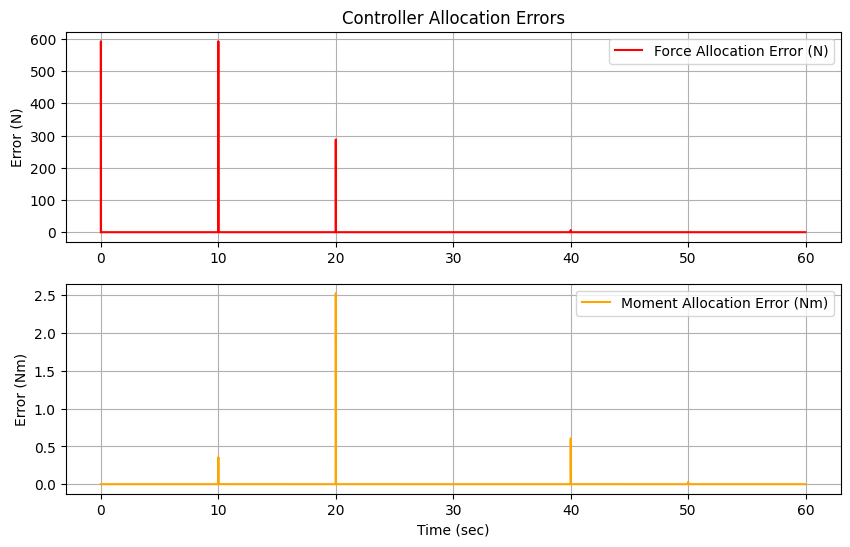

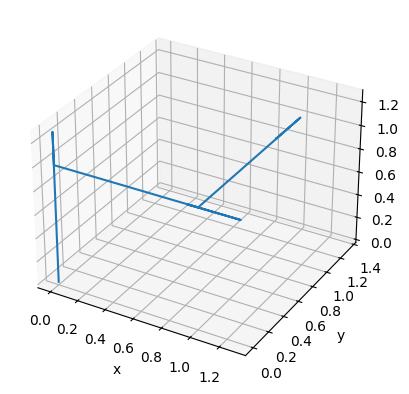

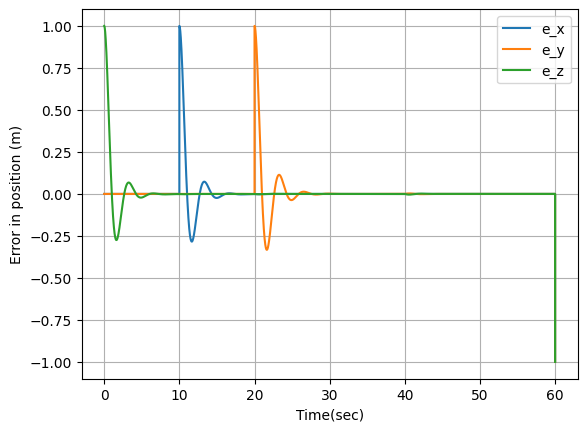

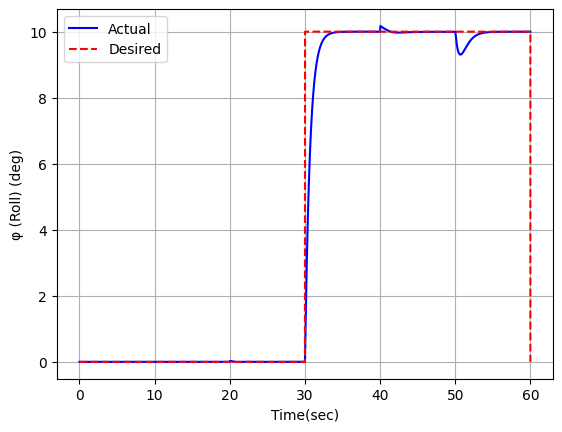

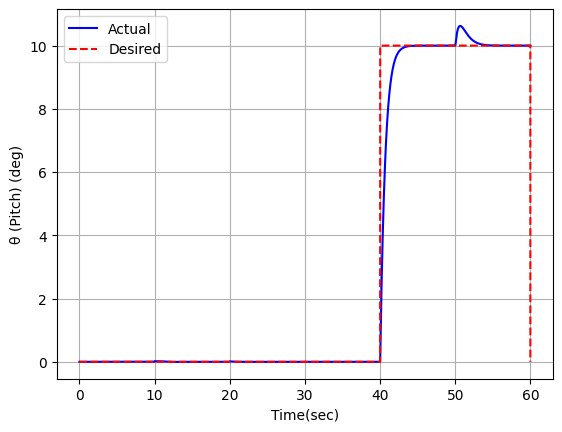

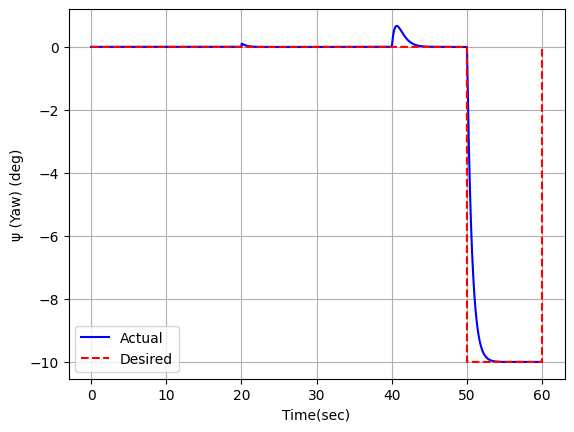

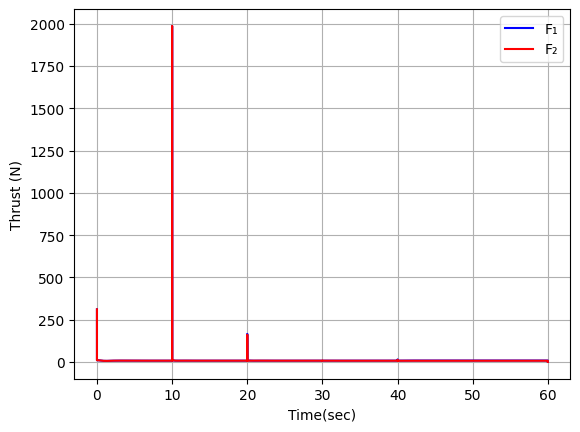

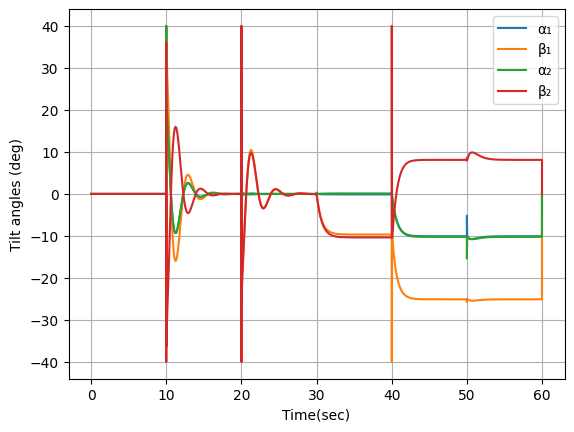

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def main():
    mass = 1.5 #kg
    I = np.diag([0.015, 0.015, 0.03])
    k = 0.017 #k_d/k_m
    l = 0.3
    g = 9.81
    max_tilt_deg = np.deg2rad(40)
    c1 = 0.03
    b1 = 0.03
    b2 = 0.05

    tspan = np.arange(0, 59.99, 0.001)

    # Note: Quadcopter and CascadedPIDController classes must be defined elsewhere
    quad = Quadcopter(mass, I, g)
    controller = CascadedPIDController(mass, g, I, max_tilt_deg, b1, b2, c1, l, k, dt=0.001)

    x = np.zeros(12)
    pos_all = np.zeros((len(tspan), 3))
    eul_all = np.zeros((len(tspan), 3))

    # Storage arrays for plotting
    t1_all = np.zeros(len(tspan))
    t2_all = np.zeros(len(tspan))
    a1_all = np.zeros(len(tspan))
    b1_all = np.zeros(len(tspan))
    a2_all = np.zeros(len(tspan))
    b2_all = np.zeros(len(tspan))
    f_err_all = np.zeros(len(tspan))
    m_err_all = np.zeros(len(tspan))

    xd, yd, zd = np.zeros(len(tspan)), np.zeros(len(tspan)), np.zeros(len(tspan))
    pd, td, psd = np.zeros(len(tspan)), np.zeros(len(tspan)), np.zeros(len(tspan))

    for i, t in enumerate(tspan[:-1]):
        # Desired Trajectory
        x_d1 = 1 if 10 <= t <= 100 else 0
        y_d1 = 1 if 20 <= t <= 100 else 0
        z_d1 = 1 if 0 <= t <= 100 else 0
        xd[i], yd[i], zd[i] = x_d1, y_d1, z_d1
        pos_desired = np.array([x_d1, y_d1, z_d1])

        phid1 = np.deg2rad(10) if 30 <= t <= 70 else 0
        thetad1 = np.deg2rad(10) if 40 <= t <= 70 else 0
        psid1 = np.deg2rad(-10) if 50 <= t <= 70 else 0
        pd[i], td[i], psd[i] = phid1, thetad1, psid1
        eul_desired = np.array([phid1, thetad1, psid1])

        # Control Calculation
        res = controller.compute_control(x, pos_desired, eul_desired)
        F_b, M_b, F1, F2, alpha1, alpha2, beta1, beta2, a, b, c, d, e, f, t1, t2, f_err, m_err = res

        # Simulation Step
        t_eval = [tspan[i], tspan[i + 1]]
        x_step = odeint(quad.dynamics, x, t_eval, args=(F_b, M_b))
        x = x_step[-1, :]

        # Log data for plotting
        t1_all[i] = t1
        t2_all[i] = t2
        a1_all[i] = alpha1
        b1_all[i] = beta1
        a2_all[i] = alpha2
        b2_all[i] = beta2
        f_err_all[i + 1] = f_err
        m_err_all[i + 1] = m_err
        pos_all[i + 1, :] = x[0:3]
        eul_all[i + 1, :] = x[9:12]

    # --- PLOTTING ---

    # Allocation Errors
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 1, 1)
    plt.plot(tspan, f_err_all, 'r', label='Force Allocation Error (N)')
    plt.grid(True)
    plt.ylabel('Error (N)')
    plt.legend()
    plt.title('Controller Allocation Errors')

    plt.subplot(2, 1, 2)
    plt.plot(tspan, m_err_all, 'orange', label='Moment Allocation Error (Nm)')
    plt.grid(True)
    plt.xlabel('Time (sec)')
    plt.ylabel('Error (Nm)')
    plt.legend()

    # 3D Trajectory
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(pos_all[:, 0], pos_all[:, 1], pos_all[:, 2])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.grid(True)

    # Position Errors
    plt.figure()
    plt.plot(tspan, xd - pos_all[:, 0], label='e_x')
    plt.plot(tspan, yd - pos_all[:, 1], label='e_y')
    plt.plot(tspan, zd - pos_all[:, 2], label='e_z')
    plt.grid(True)
    plt.legend()
    plt.xlabel('Time(sec)')
    plt.ylabel('Error in position (m)')

    # Orientation (Roll, Pitch, Yaw)
    eul_labels = ['φ (Roll)', 'θ (Pitch)', 'ψ (Yaw)']
    desired_eul = [pd, td, psd]
    for i in range(3):
        plt.figure()
        plt.plot(tspan, np.rad2deg(eul_all[:, i]), 'b', label='Actual')
        plt.plot(tspan, np.rad2deg(desired_eul[i]), 'r--', label='Desired')
        plt.grid(True)
        plt.legend()
        plt.xlabel('Time(sec)')
        plt.ylabel(f'{eul_labels[i]} (deg)')

    # CORRECTED: Thrust forces (using _all arrays)
    plt.figure()
    plt.plot(tspan, t1_all, 'b', label='F₁')
    plt.plot(tspan, t2_all, 'r', label='F₂')
    plt.grid(True)
    plt.legend()
    plt.xlabel('Time(sec)')
    plt.ylabel('Thrust (N)')

    # CORRECTED: Tilt angles (using _all arrays and converting to deg)
    plt.figure()
    plt.plot(tspan, np.rad2deg(a1_all), label='α₁')
    plt.plot(tspan, np.rad2deg(b1_all), label='β₁')
    plt.plot(tspan, np.rad2deg(a2_all), label='α₂')
    plt.plot(tspan, np.rad2deg(b2_all), label='β₂')
    plt.grid(True)
    plt.legend()
    plt.xlabel('Time(sec)')
    plt.ylabel('Tilt angles (deg)')

    plt.show()

if __name__ == "__main__":
    main()

## Implementation Notes & Comparison

### PID Controller
**Advantages of Cascaded PID:**
✓ Simpler architecture - easier to understand and tune  
✓ Linear control laws - more predictable behavior  
✓ Independent loop tuning - each controller can be adjusted separately  
✓ Anti-windup integration - prevents integral saturation  
✓ Computational efficiency - lower overhead  

### Control Loop Structure

**Cascaded PID:**
- Position (P) → Velocity Setpoint
- Velocity (PID) → Force Command Fc
- Attitude (P) → Angular Rate Setpoint
- Angular Rate (PID) → Moment Command Mc

### Neural Mixer Architecture
This cell defines the `NeuralMixer` class, a neural network designed to replace the traditional dynamic allocation mixer.

- **`__init__(self, max_thrust=15.0, max_tilt_rad=np.deg2rad(40))`**: Initializes the neural mixer with maximum thrust and tilt angle limits. It also sets up scaling buffers for input normalization and the neural network layers.
- **`forward(self, x)`**: Defines the forward pass of the neural network. It normalizes the input control commands (`Fx, Fy, Fz, Mx, My, Mz`), passes them through the network, and then denormalizes the output to physical thrusts (`t1, t2`) and tilt angles (`a1, a2, be1, be2`).
- **`init_weights(m)`**: A helper function to initialize the weights of the linear layers in the neural network using Xavier uniform initialization.

### Data Generation and Training for Neural Mixer
This cell handles the generation of training data for the `NeuralMixer` and its subsequent training process.

- **`generate_allocation_data(controller, num_samples=60000)`**: This function creates a dataset by simulating various control commands (`F_c`, `M_c`) and calculating the corresponding ideal thrusts and tilt angles using the `controller`'s `get_dynamic_M` and pseudo-inverse. It includes filtering to ensure the generated data represents physically achievable actuator outputs.
- **Data Setup**: The generated `inputs` and `targets` are converted to PyTorch tensors and loaded into a `DataLoader` for batch processing during training.
- **Model Setup**: An instance of `NeuralMixer` is created, weights are initialized, and the Adam optimizer and Mean Squared Error (`MSELoss`) criterion are configured.
- **Training Loop**: The `NeuralMixer` is trained for a specified number of epochs. A weighted loss function is used, giving higher importance to angle prediction accuracy due to its critical impact on flight stability. The loss is printed periodically to monitor training progress.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

# --- 1. Refined Neural Mixer Architecture ---
class NeuralMixer(nn.Module):
    def __init__(self, max_thrust=15.0, max_tilt_rad=np.deg2rad(40)):
        super(NeuralMixer, self).__init__()
        self.max_thrust = max_thrust
        self.max_tilt = max_tilt_rad

        # Internal Scaling buffers for input [Fx, Fy, Fz, Mx, My, Mz]
        # Keeps internal neuron activations near zero for better gradient flow
        self.register_buffer('in_scale', torch.tensor([5., 5., 5., 2., 2., 2.]))
        self.register_buffer('f_offset', torch.tensor([0., 0., 14.7, 0., 0., 0.])) # Offset for gravity

        self.net = nn.Sequential(
            nn.Linear(6, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.1),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 6),
            nn.Tanh() # Normalizes output to [-1, 1]
        )

    def forward(self, x):
        # 1. Normalize Input: (x - offset) / scale
        x_norm = (x - self.f_offset) / self.in_scale

        # 2. Forward Pass
        raw_out = self.net(x_norm)

        # 3. Denormalize to Physical Units
        # Thrust: [-1, 1] -> [0, max_thrust]
        t1 = (raw_out[:, 0:1] + 1) * 0.5 * self.max_thrust
        t2 = (raw_out[:, 1:2] + 1) * 0.5 * self.max_thrust

        # Angles: [-1, 1] -> [-max_tilt, max_tilt]
        angles = raw_out[:, 2:6] * self.max_tilt

        return torch.cat((t1, t2, angles), dim=1)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

# --- 2. Filtered Data Generation ---
def generate_allocation_data(controller, num_samples=100000):
    inputs, targets = [], []
    print(f"Generating {num_samples} high-quality samples...")

    attempts = 0
    while len(inputs) < num_samples and attempts < num_samples * 20:
        attempts += 1

        # Randomize current tilt state to learn geometry transitions
        a_curr = np.random.uniform(-0.3, 0.3)
        b_curr = np.random.uniform(-0.3, 0.3)
        M = controller.get_dynamic_M(a_curr, a_curr, b_curr, b_curr)

        # Commands: Keep lateral forces and moments smaller to maintain a clear Fz correlation
        f_cmd = np.random.uniform(-4, 4, 2).tolist() + np.random.uniform(8, 22, 1).tolist()
        m_cmd = np.random.uniform(-1.5, 1.5, 3).tolist()
        cmd = np.array(f_cmd + m_cmd)

        # Solve via Pseudo-Inverse
        thrust_raw = np.linalg.pinv(M) @ cmd
        a, b, c, d, e, f = thrust_raw
        t1, t2 = np.sqrt(a**2+b**2+c**2), np.sqrt(d**2+e**2+f**2)

        # Filter: Only keep samples the hardware can actually achieve
        if t1 > 15.0 or t2 > 15.0 or t1 < 0.2 or t2 < 0.2:
            continue

        be1, a1 = np.arctan2(-b, np.sqrt(a**2+c**2)), np.arctan2(a, c)
        be2, a2 = np.arctan2(-e, np.sqrt(d**2+f**2)), np.arctan2(d, f)

        if abs(a1) > np.deg2rad(40) or abs(be1) > np.deg2rad(40):
            continue

        inputs.append(cmd)
        targets.append([t1, t2, a1, a2, be1, be2])

    print(f"Done! Created {len(inputs)} samples.")
    return torch.FloatTensor(np.array(inputs)), torch.FloatTensor(np.array(targets))

# --- 3. Balanced Training Setup ---
# 1. Generate Data
mass = 1.5 #kg
I = np.diag([0.015, 0.015, 0.03])
k = 0.017 #k_d/k_m
l = 0.3
g = 9.81
max_tilt_deg = np.deg2rad(40)
c1 = 0.03
b1 = 0.03
b2 = 0.05

tspan = np.arange(0, 59.99, 0.001)
controller = CascadedPIDController(mass, g, I, max_tilt_deg, b1, b2, c1, l, k, dt=0.001)
inputs, targets = generate_allocation_data(controller)
dataset = TensorDataset(inputs, targets)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

# 2. Setup Model
model = NeuralMixer()
model.apply(init_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# 3. Training Loop with Weighted Angle Loss
print("Starting Balanced Training...")
for epoch in range(1001):
    model.train()
    total_loss = 0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        pred = model(batch_x)

        # Split: Thrusts (0,1) vs Angles (2,3,4,5)
        # We multiply angle loss by 25.0 because their values are small (rad),
        # but their importance for flight stability is massive.
        loss_thrust = criterion(pred[:, 0:2], batch_y[:, 0:2])
        loss_angles = criterion(pred[:, 2:6], batch_y[:, 2:6])

        loss = loss_thrust + (25.0 * loss_angles)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Weighted Loss: {total_loss/len(loader):.6f}")

print("Training Complete! The Neural Mixer is now balanced.")

Generating 100000 high-quality samples...
Done! Created 100000 samples.
Starting Balanced Training...
Epoch   0 | Weighted Loss: 3.203511
Epoch  20 | Weighted Loss: 2.587387
Epoch  40 | Weighted Loss: 2.570031
Epoch  60 | Weighted Loss: 2.559917
Epoch  80 | Weighted Loss: 2.547397
Epoch 100 | Weighted Loss: 2.537078
Epoch 120 | Weighted Loss: 2.526916
Epoch 140 | Weighted Loss: 2.511640
Epoch 160 | Weighted Loss: 2.503526
Epoch 180 | Weighted Loss: 2.488617
Epoch 200 | Weighted Loss: 2.476733
Epoch 220 | Weighted Loss: 2.463489
Epoch 240 | Weighted Loss: 2.458392
Epoch 260 | Weighted Loss: 2.440129
Epoch 280 | Weighted Loss: 2.430395
Epoch 300 | Weighted Loss: 2.419314
Epoch 320 | Weighted Loss: 2.406847
Epoch 340 | Weighted Loss: 2.397844
Epoch 360 | Weighted Loss: 2.383584
Epoch 380 | Weighted Loss: 2.373456
Epoch 400 | Weighted Loss: 2.363510
Epoch 420 | Weighted Loss: 2.354702
Epoch 440 | Weighted Loss: 2.347580
Epoch 460 | Weighted Loss: 2.336440
Epoch 480 | Weighted Loss: 2.33242

In [ ]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the path where weights will be stored
# You can change 'My Drive/Colab Notebooks/' to any folder you prefer
save_path = '/content/drive/My Drive/neural_mixer_weights.pth'

def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Successfully saved model weights to: {path}")

def load_model(model, path):
    if os.path.exists(path):
        # Load the weights into the model instance
        model.load_state_dict(torch.load(path))
        model.eval() # Set to evaluation mode
        print(f"Successfully loaded model weights from: {path}")
        return True
    else:
        print("No saved weights found at this path. Starting with fresh weights.")
        return False

# --- Usage Example ---

# To Save (Run this after your training loop):
save_model(model, save_path)

# To Load (Run this when restarting the notebook):
# model = NeuralMixer() # Initialize the architecture first
# load_model(model, save_path)

Mounted at /content/drive
Successfully saved model weights to: /content/drive/My Drive/neural_mixer_weights.pth


### Data Distribution Visualization
This cell visualizes the distribution of the generated training data (`targets_np`) for the Neural Mixer.

- **Thrust Distribution**: Histograms are plotted for `Thrust 1` and `Thrust 2` to show their distribution.
- **Angle Distribution**: A histogram is plotted for the combined angle data (alpha1, alpha2, beta1, beta2) to show their distribution.
- **Min/Max Values**: The minimum and maximum values for thrust and angles are printed to provide a summary of the data range.

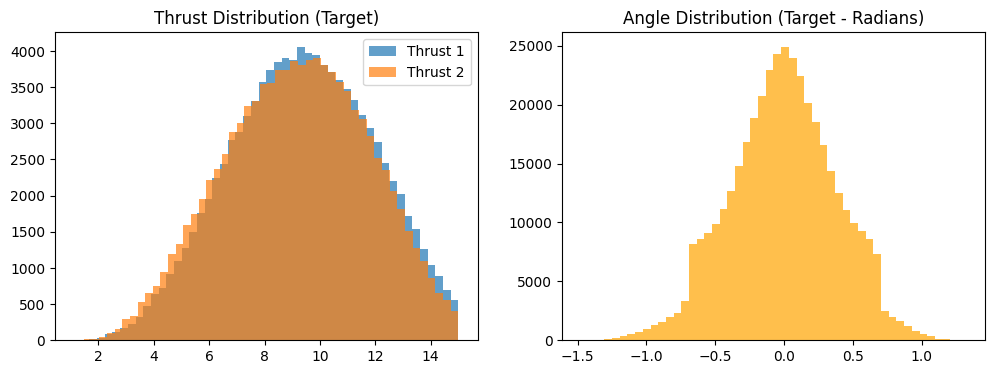

Thrust Max: 15.00 | Min: 1.12
Angle Max: 1.32 | Min: -1.47


In [ ]:
import matplotlib.pyplot as plt

# Convert to numpy for plotting
targets_np = targets.numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(targets_np[:, 0], bins=50, alpha=0.7, label='Thrust 1')
plt.hist(targets_np[:, 1], bins=50, alpha=0.7, label='Thrust 2')
plt.title("Thrust Distribution (Target)")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(targets_np[:, 2:6].flatten(), bins=50, color='orange', alpha=0.7)
plt.title("Angle Distribution (Target - Radians)")
plt.show()

print(f"Thrust Max: {targets_np[:, 0:2].max():.2f} | Min: {targets_np[:, 0:2].min():.2f}")
print(f"Angle Max: {targets_np[:, 2:6].max():.2f} | Min: {targets_np[:, 2:6].min():.2f}")

### Lift vs. Thrust Correlation Check
This cell plots the relationship between the desired vertical force (Fz) and the combined total thrust from both rotors (T1 + T2).

- **Purpose**: This scatter plot helps to verify if the generated training data correctly reflects the physical principle that a higher desired Fz should generally correspond to a higher total thrust output from the motors.

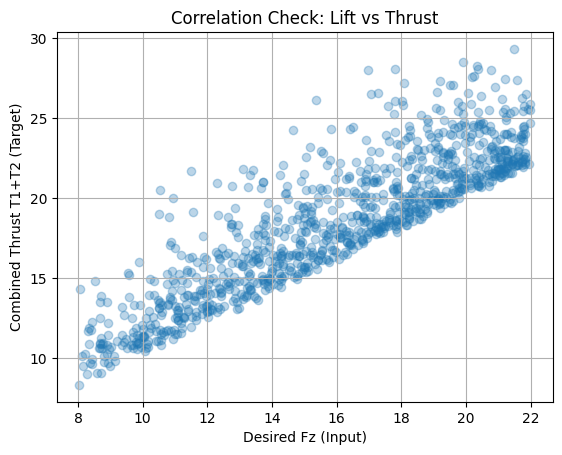

In [ ]:
# Check relationship between Vertical Force (Fz) and Total Thrust (T1 + T2)
fz_input = inputs[:, 2].numpy()
total_thrust = targets_np[:, 0] + targets_np[:, 1]

plt.scatter(fz_input[::100], total_thrust[::100], alpha=0.3)
plt.xlabel("Desired Fz (Input)")
plt.ylabel("Combined Thrust T1+T2 (Target)")
plt.title("Correlation Check: Lift vs Thrust")
plt.grid(True)
plt.show()

### Cascaded PID Controller with Neural Mixer
This cell defines the `CascadedPIDController` class, modified to integrate the trained `NeuralMixer` for dynamic allocation.

- **`__init__(self, model, mass, gravity, J, max_tilt_deg, b1, b2, c1, l, k, dt=0.001)`**: Initializes the controller, taking the `NeuralMixer` model as an argument. It sets up physical parameters, geometry constants, and PID controllers for various loops.
- **`get_dynamic_M(self, a1, a2, b1, b2)`**: This helper function remains for compatibility and internal calculations, although the primary allocation is now done by the Neural Mixer.
- **`compute_control(self, x, pos_desired, eul_desired)`**: This method is the core of the hybrid controller. It calculates force and moment commands using the cascaded PID loops, then feeds these commands into the `NeuralMixer` to get the actual actuator thrusts and tilt angles. It also reconstructs 'raw' signals for logging and applies constraints before returning the realized body forces and moments, along with other logging data.

In [ ]:
class CascadedPIDController:
    def __init__(self, model, mass, gravity, J, max_tilt_deg, b1, b2, c1, l, k, dt=0.001):
        self.model = model
        if self.model is not None:
            self.model.eval()

        self.mass = mass
        self.gravity = gravity
        self.J = J
        self.gravity_force = np.array([0, 0, self.mass * self.gravity])

        self.max_tilt_deg = max_tilt_deg
        self.b1, self.b2, self.c1, self.l, self.k = b1, b2, c1, l, k
        self.dt = dt

        # PID Controllers
        self.Kp_pos = 3.0
        self.vel_pid_x = PIDController(Kp=2.4, Ki=0.5, Kd=0.2, dt=dt, integral_limit=5.0)
        self.vel_pid_y = PIDController(Kp=2.2, Ki=0.5, Kd=0.1, dt=dt, integral_limit=5.0)
        self.vel_pid_z = PIDController(Kp=2.5, Ki=0.5, Kd=0.2, dt=dt, integral_limit=5.0)
        self.Kp_att = 1.2
        self.angrate_pid_p = PIDController(Kp=1.2, Ki=0.1, Kd=0.01, dt=dt, integral_limit=3.0)
        self.angrate_pid_q = PIDController(Kp=1.2, Ki=0.1, Kd=0.01, dt=dt, integral_limit=3.0)
        self.angrate_pid_r = PIDController(Kp=1.2, Ki=0.1, Kd=0.01, dt=dt, integral_limit=2.0)

    def get_dynamic_M(self, a1, a2, b1, b2):
        l1 = np.array([(self.b1 + self.b2 * np.cos(b1)) * np.sin(a1), self.l - self.b2 * np.sin(b1), self.c1 + (self.b1 + self.b2 * np.cos(b1)) * np.cos(a1)])
        l2 = np.array([(self.b1 + self.b2 * np.cos(b2)) * np.sin(a2), -(self.l + self.b2 * np.sin(b2)), self.c1 + (self.b1 + self.b2 * np.cos(b2)) * np.cos(a2)])
        return np.array([
            [1, 0, 0, 1, 0, 0], [0, 1, 0, 0, 1, 0], [0, 0, 1, 0, 0, 1],
            [-self.k, -l1[2], l1[1], self.k, -l2[2], l2[1]],
            [l1[2], self.k, -l1[0], l2[2], -self.k, -l2[0]],
            [-l1[1], l1[0], -self.k, -l2[1], l2[0], self.k]
        ])

    def compute_control(self, x, pos_desired, eul_desired):
        # 1. State Extraction
        pos, vel, omega, angles = x[0:3], x[3:6], x[6:9], x[9:12]
        phi, theta, psi = [wrapToPi(a) for a in angles]

        R = np.array([[np.cos(psi)*np.cos(theta), np.cos(psi)*np.sin(theta)*np.sin(phi)-np.sin(psi)*np.cos(phi), np.cos(psi)*np.sin(theta)*np.cos(phi)+np.sin(psi)*np.sin(phi)],
                      [np.sin(psi)*np.cos(theta), np.sin(psi)*np.sin(theta)*np.sin(phi)+np.cos(psi)*np.cos(phi), np.sin(psi)*np.sin(theta)*np.cos(phi)-np.cos(psi)*np.sin(phi)],
                      [-np.sin(theta), np.cos(theta)*np.sin(phi), np.cos(theta)*np.cos(phi)]])

        # 2. Force/Moment Generation
        vel_sp = self.Kp_pos * (pos_desired - pos)
        F_inertial = np.array([self.vel_pid_x.update(vel_sp[0]-vel[0]), self.vel_pid_y.update(vel_sp[1]-vel[1]), self.vel_pid_z.update(vel_sp[2]-vel[2])]) + self.gravity_force
        F_c = R.T @ F_inertial

        rate_sp = self.Kp_att * (eul_desired - np.array([phi, theta, psi]))
        M_c = np.array([self.angrate_pid_p.update(rate_sp[0]-omega[0]), self.angrate_pid_q.update(rate_sp[1]-omega[1]), self.angrate_pid_r.update(rate_sp[2]-omega[2])])

        # 3. Neural Allocation
        cmd_in = np.concatenate((F_c, M_c)).astype(np.float32)
        with torch.no_grad():
            pred = self.model(torch.from_numpy(cmd_in).unsqueeze(0)).squeeze(0).numpy()

        t1, t2, a1_n, a2_n, be1_n, be2_n = pred

        # Reconstruct "raw" signals for logging (a, b, c, d, e, f)
        a = t1 * np.sin(a1_n) * np.cos(be1_n)
        b = -t1 * np.sin(be1_n)
        c = t1 * np.cos(a1_n) * np.cos(be1_n)
        d = t2 * np.sin(a2_n) * np.cos(be2_n)
        e = -t2 * np.sin(be2_n)
        f = t2 * np.cos(a2_n) * np.cos(be2_n)

        # 4. Constraints & Forward Physics
        alpha1, alpha2, beta1, beta2 = clampAngles(a1_n, a2_n, be1_n, be2_n, self.max_tilt_deg)
        F1, F2 = np.clip(t1, 0, 15.0), np.clip(t2, 0, 15.0)

        M_real = self.get_dynamic_M(alpha1, alpha2, beta1, beta2)
        T1v = np.array([F1*np.sin(alpha1)*np.cos(beta1), -F1*np.sin(beta1), F1*np.cos(alpha1)*np.cos(beta1)])
        T2v = np.array([F2*np.sin(alpha2)*np.cos(beta2), -F2*np.sin(beta2), F2*np.cos(alpha2)*np.cos(beta2)])
        res = M_real @ np.concatenate((T1v, T2v))

        F_b, M_b = res[0:3], res[3:6]
        f_err, m_err = np.linalg.norm(F_c - F_b), np.linalg.norm(M_c - M_b)

        # RETURN 18 VALUES:
        return (F_b, M_b, F1, F2, alpha1, alpha2, beta1, beta2,
                a, b, c, d, e, f, t1, t2, f_err, m_err)

### Main Simulation Function (Neural Mixer)
This cell contains the `main` function for running the complete closed-loop simulation, now utilizing the `CascadedPIDController` with the integrated `NeuralMixer` for dynamic allocation.

- **Constants**: Defines physical parameters of the bi-rotor vehicle.
- **Initialization**: Creates `Quadcopter` and the *new* `CascadedPIDController` (with the neural mixer) instances, and initializes state and logging arrays.
- **Simulation Loop**: Iterates through `tspan`, generates desired trajectory setpoints, computes control commands using the neural mixer, integrates dynamics, and logs results.
- **Plotting**: Generates various plots to visualize the simulation results, including 3D trajectory, allocation errors (between desired and realized forces/moments), position tracking, orientation tracking, motor thrust forces, and servo tilt angles.

In [ ]:
ramp_duration = 5.0

def get_ramp_value(current_t, start_t, end_t, target_val, duration):
    if current_t < start_t:
        return 0.0
    elif current_t > end_t:
        return 0.0 # Or target_val if you want it to stay at the target after end_t

    # Calculate the ramp up
    if current_t < (start_t + duration):
        return target_val * (current_t - start_t) / duration
    # Calculate the ramp down (optional - remove if you want it to stay high until end_t)
    elif current_t > (end_t - duration):
        return target_val * (end_t - current_t) / duration
    else:
        return target_val

Running Neural Mixer Simulation...


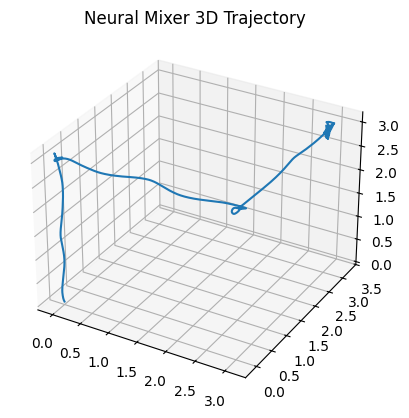

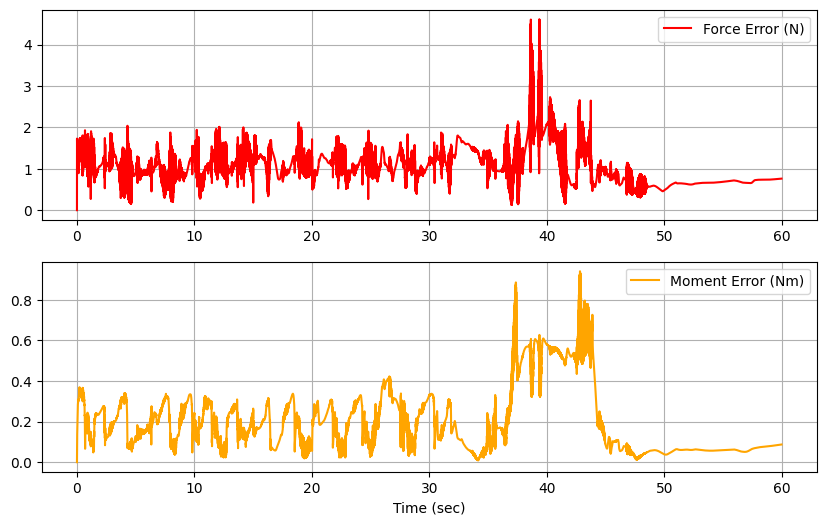

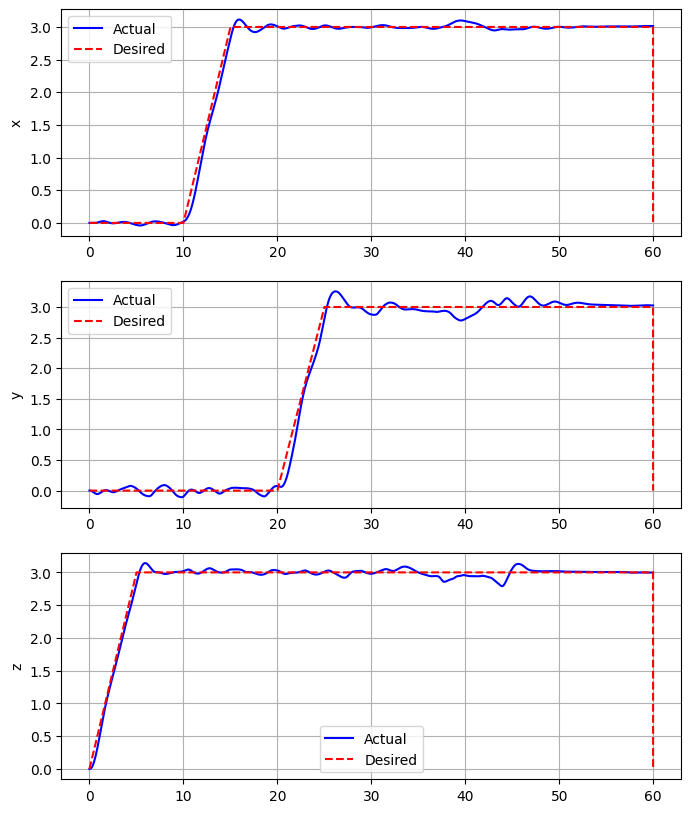

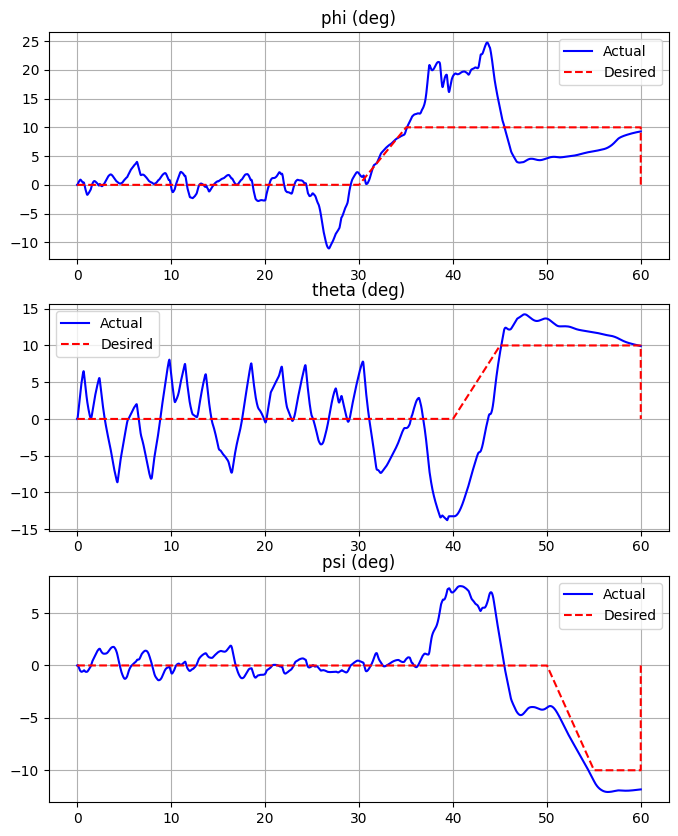

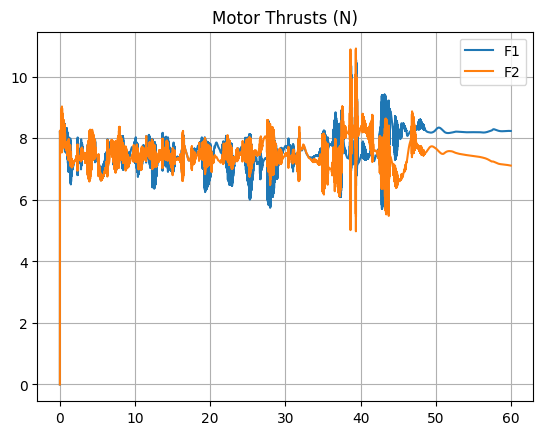

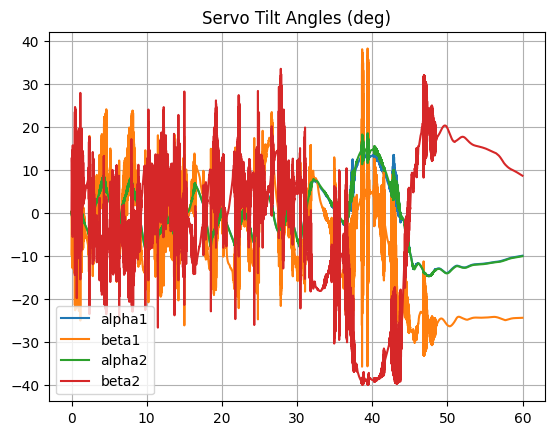

In [ ]:
def main():
    # --- Constants ---
    mass = 1.5
    I = np.diag([0.015, 0.015, 0.03])
    k = 0.017
    l = 0.3
    g = 9.81
    max_tilt_deg = np.deg2rad(40)
    c1, b1, b2 = 0.03, 0.03, 0.05
    dt = 0.005
    tspan = np.arange(0, 59.99, dt)

    # --- Initialization ---
    # Ensure 'model' is the trained NeuralMixer object from your previous cell
    quad = Quadcopter(mass, I, g)
    controller = CascadedPIDController(model, mass, g, I, max_tilt_deg, b1, b2, c1, l, k, dt=dt)

    x = np.zeros(12)
    pos_all = np.zeros((len(tspan), 3))
    vel_all = np.zeros((len(tspan), 3))
    eul_all = np.zeros((len(tspan), 3))

    # Logging Arrays
    f_err_all = np.zeros(len(tspan))
    m_err_all = np.zeros(len(tspan))
    f1_all, f2_all = np.zeros(len(tspan)), np.zeros(len(tspan))
    alpha1_all, alpha2_all = np.zeros(len(tspan)), np.zeros(len(tspan))
    beta1_all, beta2_all = np.zeros(len(tspan)), np.zeros(len(tspan))

    # Trajectory Arrays
    xd, yd, zd = np.zeros(len(tspan)), np.zeros(len(tspan)), np.zeros(len(tspan))
    pd, td, psd = np.zeros(len(tspan)), np.zeros(len(tspan)), np.zeros(len(tspan))

    print("Running Neural Mixer Simulation...")
    for i, t in enumerate(tspan[:-1]):
        # Trajectory Generation
        # --- Position Ramps ---
        x_d1 = get_ramp_value(t, 10, 100, 3, ramp_duration)
        y_d1 = get_ramp_value(t, 20, 100, 3, ramp_duration)
        z_d1 = get_ramp_value(t, 0, 100, 3, ramp_duration)

        xd[i], yd[i], zd[i] = x_d1, y_d1, z_d1
        pos_desired = np.array([x_d1, y_d1, z_d1])

        # --- Orientation Ramps ---
        # Note: target degrees converted to radians
        target_angle = np.deg2rad(10)
        target_psi = np.deg2rad(-10)

        phid1   = get_ramp_value(t, 30, 70, target_angle, ramp_duration)
        thetad1 = get_ramp_value(t, 40, 70, target_angle, ramp_duration)
        psid1   = get_ramp_value(t, 50, 70, target_psi, ramp_duration)
        pd[i], td[i], psd[i] = phid1, thetad1, psid1
        eul_desired = np.array([phid1, thetad1, psid1])

        # Compute Control (Neural Mixer)
        res = controller.compute_control(x, pos_desired, eul_desired)
        F_b, M_b, F1, F2, a1, a2, be1, be2, a, b, c, d, e, f, t1, t2, f_err, m_err = res

        # Dynamics Integration
        t_eval = [tspan[i], tspan[i + 1]]
        x_step = odeint(quad.dynamics, x, t_eval, args=(F_b, M_b))
        x = x_step[-1, :]

        # Logging
        pos_all[i + 1, :] = x[0:3]
        eul_all[i + 1, :] = x[9:12]
        f_err_all[i + 1] = f_err
        m_err_all[i + 1] = m_err
        f1_all[i + 1], f2_all[i + 1] = F1, F2
        alpha1_all[i + 1], alpha2_all[i + 1] = np.rad2deg(a1), np.rad2deg(a2)
        beta1_all[i + 1], beta2_all[i + 1] = np.rad2deg(be1), np.rad2deg(be2)

    # --- PLOTTING ---

    # 1. 3D Path
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(pos_all[:, 0], pos_all[:, 1], pos_all[:, 2])
    ax.set_title("Neural Mixer 3D Trajectory")

    # 2. Allocation Errors
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 1, 1)
    plt.plot(tspan, f_err_all, 'r', label='Force Error (N)')
    plt.grid(True); plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(tspan, m_err_all, 'orange', label='Moment Error (Nm)')
    plt.grid(True); plt.legend(); plt.xlabel('Time (sec)')

    # 3. Position Tracking
    fig, axs = plt.subplots(3, 1, figsize=(8, 10))
    labels = ['x', 'y', 'z']
    targets = [xd, yd, zd]
    for idx, ax in enumerate(axs):
        ax.plot(tspan, pos_all[:, idx], 'b', label='Actual')
        ax.plot(tspan, targets[idx], 'r--', label='Desired')
        ax.set_ylabel(labels[idx]); ax.grid(True); ax.legend()

    # 4. Orientation Tracking
    fig, axs = plt.subplots(3, 1, figsize=(8, 10))
    titles = ['phi (deg)', 'theta (deg)', 'psi (deg)']
    e_targets = [np.rad2deg(pd), np.rad2deg(td), np.rad2deg(psd)]
    for idx, ax in enumerate(axs):
        ax.plot(tspan, np.rad2deg(eul_all[:, idx]), 'b', label='Actual')
        ax.plot(tspan, e_targets[idx], 'r--', label='Desired')
        ax.set_title(titles[idx]); ax.grid(True); ax.legend()

    # 5. Thrusts
    plt.figure()
    plt.plot(tspan, f1_all, label='F1')
    plt.plot(tspan, f2_all, label='F2')
    plt.title("Motor Thrusts (N)"); plt.grid(True); plt.legend()

    # 6. Tilt Angles
    plt.figure()
    plt.plot(tspan, alpha1_all, label='alpha1')
    plt.plot(tspan, beta1_all, label='beta1')
    plt.plot(tspan, alpha2_all, label='alpha2')
    plt.plot(tspan, beta2_all, label='beta2')
    plt.title("Servo Tilt Angles (deg)"); plt.grid(True); plt.legend()

    plt.show()

if __name__ == "__main__":
    main()